In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from astropy.time import Time
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
np.random.seed(42)

In [25]:
injections = pd.read_csv('injections_cleaned.csv')
allsky = pd.read_csv('allsky_cleaned.csv')

In [5]:
allsky = pd.read_csv('allsky_cleaned.csv')
injections_all = pd.read_csv('injections_cleaned.csv')

# Drop invalid rows (text export often adds one trailing NaN row).
valid = injections_all[['mass1', 'mass2', 'spin1z', 'spin2z', 'distance']].notna().all(axis=1)
injections_all = injections_all.loc[valid].copy().reset_index(drop=True)

# bayestar-inject stores detector-frame masses in injections.dat.
# Convert to source-frame for ejecta calculations.
redshift_all = np.array([
    z_at_value(cosmo.luminosity_distance, d * u.Mpc).value
    for d in injections_all['distance'].values
])
injections_all['redshift'] = np.around(redshift_all, decimals=7)

# Switch mass1 and mass2 to make sure mass1 >= mass2
swap = injections_all['mass1'] < injections_all['mass2']
injections_all.loc[swap, ['mass1', 'mass2']] = injections_all.loc[swap, ['mass2', 'mass1']].values
injections_all.loc[swap, ['spin1z', 'spin2z']] = injections_all.loc[swap, ['spin2z', 'spin1z']].values

injections_all['mass1_detector'] = injections_all['mass1'].values
injections_all['mass2_detector'] = injections_all['mass2'].values
injections_all['mass1_source'] = np.around(injections_all['mass1_detector'] / (1 + redshift_all), decimals=7)
injections_all['mass2_source'] = np.around(injections_all['mass2_detector'] / (1 + redshift_all), decimals=7)

# BNS selection should be done in source frame.
bns_index = np.logical_and(
    injections_all['mass1_source'] < 2.0606,
    injections_all['mass2_source'] < 2.0606,
)
injections = injections_all.loc[bns_index].copy()
allsky = allsky.loc[bns_index].copy().reset_index(drop=True)

print(f'Total valid injections: {len(injections_all)}')
print(f'BNS injections (source-frame cut): {len(injections)}')
print(f"mass2_detector max: {injections['mass2_detector'].max():.4f}")
print(f"mass2_source   max: {injections['mass2_source'].max():.4f}")
injections[['mass1_detector','mass2_detector','mass1_source','mass2_source','redshift']].head()


Total valid injections: 1822
BNS injections (source-frame cut): 1822
mass2_detector max: 1.7515
mass2_source   max: 1.4842


,mass1_detector,mass2_detector,mass1_source,mass2_source,redshift
0,1.365921,1.267186,1.292318,1.198903,0.056954
1,1.610441,1.560871,1.362978,1.321025,0.181561
2,1.415086,1.406627,1.316810,1.308938,0.074632
3,1.534667,1.418852,1.437474,1.328994,0.067613
4,1.536066,1.529759,1.313497,1.308104,0.169448


Using SFHo EOS to calculate compactness C. The grid data is saved at 'eos.mr'.

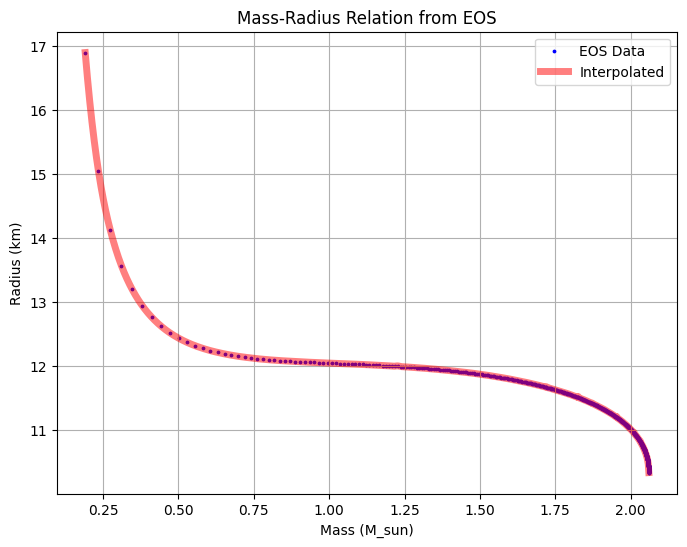

In [7]:
eos = pd.read_csv('eos.mr', names=['radius', 'mass'], sep='\s+', skiprows=1)

mass = eos['mass'].values
radius = eos['radius'].values
f = interp1d(mass, radius, kind='cubic', fill_value="extrapolate")
mass_int = np.linspace(mass.min(), mass.max(), 1000)
radius1 = f(mass_int)

plt.figure(figsize=(8,6))
plt.scatter(mass, radius, label='EOS Data', color='b',s=3)
plt.plot(mass_int, radius1, label='Interpolated', color='r', alpha=0.5, linewidth=5)
plt.xlabel('Mass (M_sun)')
plt.ylabel('Radius (km)')
plt.title('Mass-Radius Relation from EOS')
plt.legend()
plt.grid()

In [8]:
def compute_radius(mass, eos_file):
    eos = pd.read_csv(eos_file, names=['radius', 'mass'], sep='\s+', skiprows=1)
    mass_eos = eos['mass'].values
    radius_eos = eos['radius'].values
    f = interp1d(mass_eos, radius_eos, kind='cubic', fill_value="extrapolate")
    radius = f(mass)
    return radius

In [9]:
mass1 = injections['mass1'].values
mass2 = injections['mass2'].values

radius1 = np.around(f(mass1),decimals=6)
radius2 = np.around(f(mass2),decimals=6)
injections['radius1'] = radius1
injections['radius2'] = radius2

In [10]:
def compute_compactness(mass, radius):

    G = 6.67430e-11  # m^3 kg^-1 s^-2
    c = 299792458    # m/s
    Ms = 1.98855e30  # kg
    C = (G * mass * Ms) / (c**2 * radius * 1000)  # radius in km to m
    return np.around(C, decimals=5)

compactness1 = compute_compactness(mass1, radius1)
compactness2 = compute_compactness(mass2, radius2)
injections['compactness1'] = compactness1
injections['compactness2'] = compactness2

## Compute ejecta mass
In Bulla KN model, ejecta has two components: dynamical ejecta and wind ejecta. We can calculate them with gravitational wave parameters. 

Reference: *Predictions for electromagnetic counterparts to Neutron Star mergers discovered during LIGO-Virgo-KAGRA observing runs 4 and 5*

For dynamical ejecta mass, 
$log_{10}(m^{dyn fit}_{ej})=[a\frac{(1-2C_1)M_1}{C_1}+bM_2(\frac{M_1}{M_2})^n+\frac{d}{2}]+[1\leftrightarrow 2]$
, where $a=-0.0719, b=0.2116, d=-2.42, n=-2.905$;

$C=\frac{GW}{c^2R}$

In [11]:
def dynamical_ejecta_mass(m1, m2, c1, c2):
    a = -0.0719
    b = 0.2116
    d = -2.42
    n = -2.905
    
    term1 = (a * (1 - 2 * c1) * m1 / c1) + (b * m2 * (m1 / m2) ** n) + (d / 2)
    term2 = (a * (1 - 2 * c2) * m2 / c2) + (b * m1 * (m2 / m1) ** n) + (d / 2)
    
    log_mej_dyn = term1 + term2
    mej_dyn = 10 ** log_mej_dyn
    
    return mej_dyn

In [12]:
mej_dyn_fit = dynamical_ejecta_mass(mass1, mass2, compactness1, compactness2)
mej_dyn = np.minimum(0.09, mej_dyn_fit)
injections['mej_dyn'] = np.around(mej_dyn, decimals=6)
print("Dynamical Ejecta Mass(M_sun):")
print(mej_dyn)

Dynamical Ejecta Mass(M_sun):
[0.00234015 0.00364401 0.00264491 ... 0.00288679 0.00258773 0.00233647]


For wind ejcta mass:

$m_{ej}^{wind}=\zeta m_{disc}$, $\zeta$ is sampled uniformly from $[0.1,0.4]$;

$log_{10}(m_{disk})=max(-3,a(1+b \cdot \tanh[\frac{c-(M_1+M_2)/M_{thr}}{d}]))$,where $a=-31.335,b=-0.9760,c=1.0474,d=0.05957$;

$M_{thr} = (2.38-3.606\frac{M_{TOV}}{R_{1.6M_{\odot}}})M_{TOV}$,$M_{TOV}=2.05M_{\odot}$

In [13]:
def compute_wind_ejecta_mass(m1, m2, Mthr, zeta):
    a = -31.335
    b = -0.9760
    c = 1.0474
    d = 0.05957
    
    Mtot = m1 + m2
    log_mdisk = np.maximum(-3, a * (1 + b * np.tanh((c - Mtot / Mthr) / d)))
    mdisk = 10 ** log_mdisk
    
    mej_wind = zeta * mdisk
    return mej_wind

In [14]:
Rthr = f(1.6)
MTOV = 2.05  # in solar masses
Mthr = (2.38 - 3.606 * (MTOV / Rthr)) * MTOV
print("Radius at 1.6M_sun R_1.6(km):", Rthr)
print("Threshold Mass M_thr(M_sun):", Mthr)

Radius at 1.6M_sun R_1.6(km): 11.790587325737482
Threshold Mass M_thr(M_sun): 3.593719243296717


In [15]:
zeta = np.random.uniform(0.1, 0.4, size=len(mass1))
mej_wind = compute_wind_ejecta_mass(mass1, mass2, Mthr, zeta)
injections['mej_wind'] = np.around(mej_wind, decimals=6)
print("Wind Ejecta Mass(M_sun):")
print(mej_wind)

Wind Ejecta Mass(M_sun):
[0.0374507  0.03925403 0.05538356 ... 0.0370712  0.02853452 0.02401031]


If $m_1+m_2 \geq M_{thr}$, set both dynamical and wind ejcta to zero.

In [16]:
index = np.where((mass1 + mass2) >= Mthr)[0]
print("Indices with total mass >= M_thr:", index)
injections.loc[index, 'mej_dyn'] = 0.0
injections.loc[index, 'mej_wind'] = 0.0

Indices with total mass >= M_thr: []


Save new injections parameters.

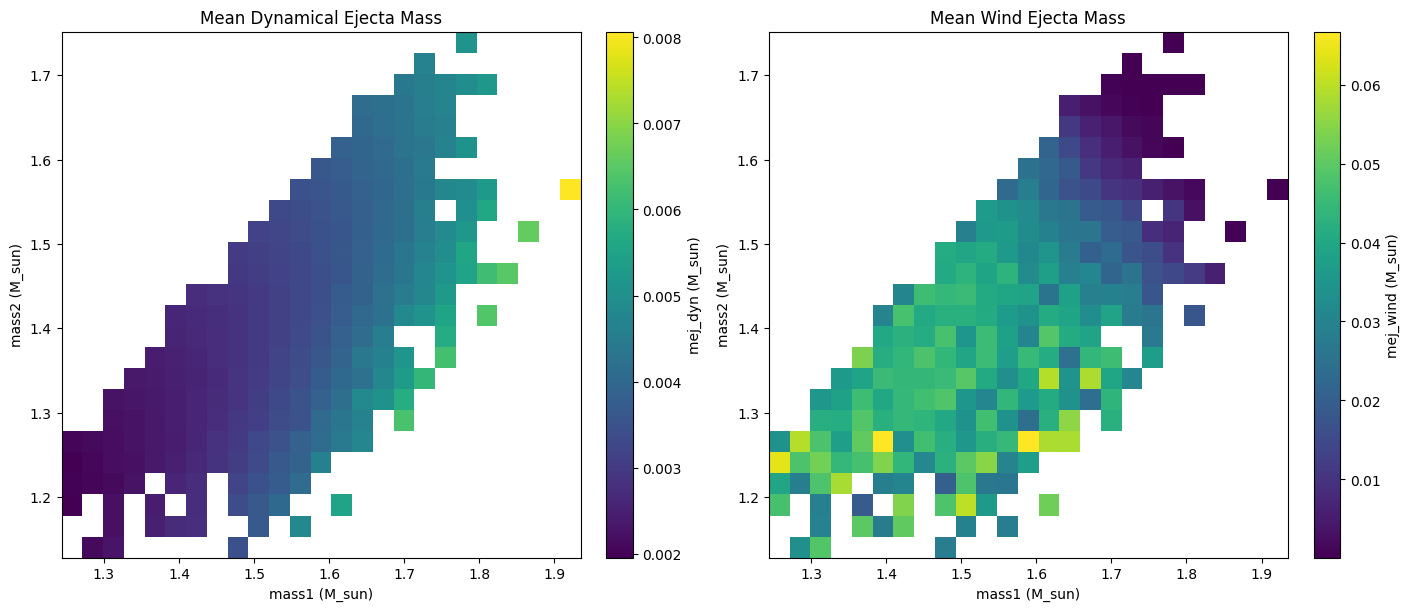

In [17]:
# Heatmaps of ejecta masses vs (mass1, mass2)
bins = 25

# 2D mean for dynamical ejecta
H_sum_dyn, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_dyn)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean_dyn = H_sum_dyn / np.where(H_count == 0, np.nan, H_count)

# 2D mean for wind ejecta
H_sum_wind, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges], weights=mej_wind)
H_mean_wind = H_sum_wind / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean_dyn.T, cmap='viridis', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Dynamical Ejecta Mass')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mej_dyn (M_sun)')

im1 = axs[1].pcolormesh(xedges, yedges, H_mean_wind.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Mean Wind Ejecta Mass')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('mej_wind (M_sun)')

plt.show()

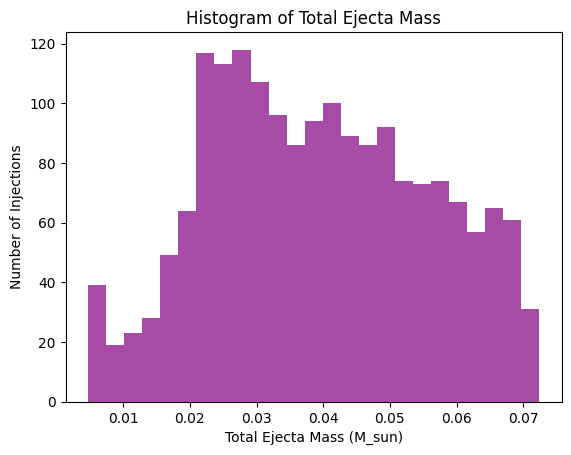

In [18]:
# total mass of ejecta
mej_total = mej_dyn + mej_wind
injections['mej_total'] = np.around(mej_total, decimals=6)

plt.hist(injections['mej_total'], bins=25, color='purple', alpha=0.7)
plt.xlabel('Total Ejecta Mass (M_sun)')
plt.ylabel('Number of Injections')
plt.title('Histogram of Total Ejecta Mass')
plt.show()

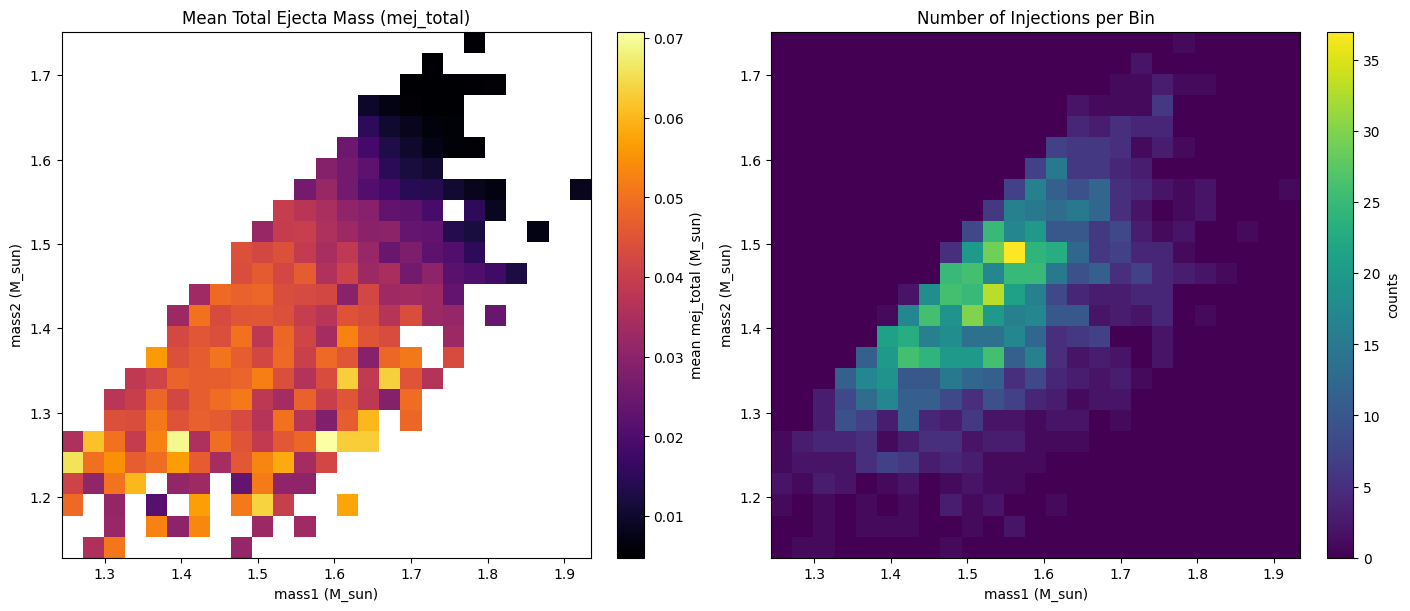

In [19]:
# 2D mean (and count) of total ejecta mass vs (mass1, mass2)
bins = 25

H_sum, xedges, yedges = np.histogram2d(mass1, mass2, bins=bins, weights=mej_total)
H_count, _, _ = np.histogram2d(mass1, mass2, bins=[xedges, yedges])
H_mean = H_sum / np.where(H_count == 0, np.nan, H_count)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

im0 = axs[0].pcolormesh(xedges, yedges, H_mean.T, cmap='inferno', shading='auto')
axs[0].set_xlabel('mass1 (M_sun)')
axs[0].set_ylabel('mass2 (M_sun)')
axs[0].set_title('Mean Total Ejecta Mass (mej_total)')
c0 = fig.colorbar(im0, ax=axs[0])
c0.set_label('mean mej_total (M_sun)')

# show counts in the other panel
im1 = axs[1].pcolormesh(xedges, yedges, H_count.T, cmap='viridis', shading='auto')
axs[1].set_xlabel('mass1 (M_sun)')
axs[1].set_ylabel('mass2 (M_sun)')
axs[1].set_title('Number of Injections per Bin')
c1 = fig.colorbar(im1, ax=axs[1])
c1.set_label('counts')

plt.show()

Add half-opening angle($\Phi$) and observing angle($Cos\Theta$).

$\Phi \in U(15^o, 75^o)$, $\Theta=min(\iota, \pi-\iota)$ 

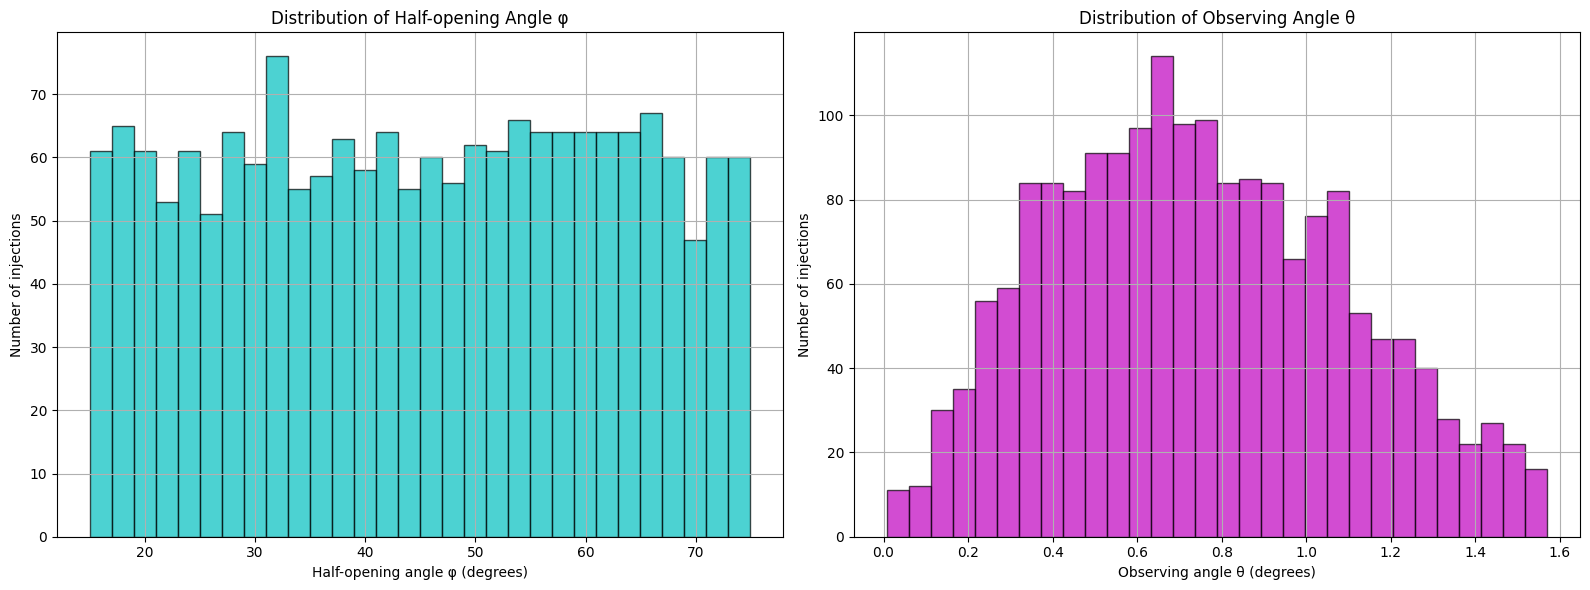

In [20]:
# half-opening angle phi
phi = np.random.uniform(15, 75, size=len(mass1))

# observing angle theta
inclination = injections['inclination'].values
theta = np.where(inclination <= np.pi/2, inclination, (np.pi - inclination))

plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.hist(phi, bins=30, color='c', edgecolor='k', alpha=0.7)
plt.xlabel('Half-opening angle φ (degrees)')
plt.ylabel('Number of injections')
plt.title('Distribution of Half-opening Angle φ')
plt.grid()
plt.subplot(1,2,2)
plt.hist(theta, bins=30, color='m', edgecolor='k', alpha=0.7)
plt.xlabel('Observing angle θ (degrees)')
plt.ylabel('Number of injections')
plt.title('Distribution of Observing Angle θ')
plt.grid()
plt.tight_layout()

injections['phi'] = np.around(phi, decimals=6)
injections['costheta'] = np.around(np.cos(theta), decimals=6)

### Add distance and uncertainty in skymap.

In [21]:
ra = np.rad2deg(injections['longitude'].values)
dec = np.rad2deg(injections['latitude'].values)

injections['ra'] = np.around(ra, decimals=6)
injections['dec'] = np.around(dec, decimals=6)

In [22]:
distmean = allsky['distmean'].values
diststd = allsky['diststd'].values

injections['distmean'] = np.around(distmean, decimals=6)
injections['diststd'] = np.around(diststd, decimals=6)

In [23]:
# add GPS time and mjd time columns
mjd_min = 61000.0
mjd_max = 64500.0
mjd_times = np.random.uniform(mjd_min, mjd_max, size=len(injections))
gps_times = Time(mjd_times, format='mjd').gps

injections['mjd_time'] = np.around(mjd_times, decimals=4)
injections['gps_time'] = np.around(gps_times, decimals=2)

/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1230 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [24]:
# re-order columns
cols = list(injections.columns)
cols.insert(1, cols.pop(cols.index('mjd_time')))
cols.insert(2, cols.pop(cols.index('gps_time')))
cols.insert(5, cols.pop(cols.index('ra')))
cols.insert(6, cols.pop(cols.index('dec')))

injections = injections[cols]
print(injections.columns)

Index(['simulation_id', 'mjd_time', 'gps_time', 'longitude', 'latitude', 'ra',
       'dec', 'inclination', 'distance', 'mass1', 'mass2', 'spin1z', 'spin2z',
       'redshift', 'mass1_detector', 'mass2_detector', 'mass1_source',
       'mass2_source', 'radius1', 'radius2', 'compactness1', 'compactness2',
       'mej_dyn', 'mej_wind', 'mej_total', 'phi', 'costheta', 'distmean',
       'diststd'],
      dtype='object')


In [25]:
injections

,simulation_id,mjd_time,gps_time,longitude,latitude,ra,dec,inclination,distance,mass1,...,radius2,compactness1,compactness2,mej_dyn,mej_wind,mej_total,phi,costheta,distmean,diststd
0,0,63662.0147,1.677716e+09,5.923145,1.053362,339.371210,60.353203,2.030131,263.14581,1.365921,...,11.977060,0.16895,0.15624,0.002340,0.037451,0.039791,51.900778,0.443352,553.355833,194.809759
1,2,61540.7227,1.494437e+09,1.652701,-0.550674,94.692769,-31.551290,2.094593,909.13148,1.610441,...,11.822530,0.20186,0.19497,0.003644,0.039254,0.042898,61.478027,0.500171,1089.464086,313.045394
2,4,62705.4287,1.595067e+09,3.622934,0.585640,207.578845,33.554676,2.643234,349.08993,1.415086,...,11.919723,0.17536,0.17427,0.002645,0.055384,0.058028,53.634255,0.878368,340.888005,81.303502
3,6,62504.9482,1.577746e+09,2.957829,-0.543259,169.471101,-31.126445,1.758482,314.73277,1.534667,...,11.914252,0.19135,0.17586,0.003125,0.046030,0.049155,46.818128,0.186585,613.537831,207.609617
4,7,63089.1874,1.628224e+09,0.514571,-1.015352,29.482761,-58.175390,2.956676,842.37707,1.536066,...,11.846699,0.19154,0.19069,0.003283,0.021134,0.024417,17.517073,0.982952,640.240711,173.213419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1817,2302,61845.8062,1.520796e+09,3.210527,-0.385060,183.949624,-22.062325,1.068058,970.92365,1.707780,...,11.896254,0.21595,0.18024,0.004543,0.035658,0.040201,27.452456,0.481827,983.396732,357.850454
1818,2303,61238.1306,1.468293e+09,4.021694,1.048652,230.426087,60.083334,2.047053,548.20478,1.431957,...,11.927566,0.17758,0.17240,0.002666,0.049776,0.052443,29.288799,0.458456,719.774074,186.185511
1819,2304,62109.1645,1.543550e+09,0.156234,1.260005,8.951557,72.192992,0.573228,424.12914,1.486903,...,11.947877,0.18490,0.16677,0.002887,0.037071,0.039958,69.506073,0.840155,383.720517,116.397161
1820,2305,61933.7809,1.528397e+09,2.163984,0.393127,123.987150,22.524545,3.071045,309.62619,1.402309,...,11.993011,0.17369,0.14917,0.002588,0.028535,0.031122,43.084143,0.997513,276.991479,69.966577


In [26]:
injections.to_csv('injections_final.csv', index=False)